In [ ]:
#=== COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "dplant227"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Final-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam


# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: May 11, 2026

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=10$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

The objective of this experiment is to determine the optimal combination of ingredients: Protein, Salsa and Potatoes, for Buster's Breakfast Burritos that maximizes customer satisfaction.

2. State the outcome variable and how it was measured.

The outcome variable is Customer Satisfaction. This is a nominal discrete variable rated on a scale from 1 to 10, with 1 being terrible to 10 being amazing.

3. State the independent variables. What lurking variables may be present?

The independent variables are Protein with 3 levels, Salsa with 2 levels, Potatoes with 2 levels. These are ordinal values. Potential lurking variables could be the time of day, baseline hunger, the size of the burrito, the weight of the participant, spice tolerances, temperature of the burrito.

4. Why might a full factorial design be preferred in this specific instance to a $2^k$ fractional factorial design?

A full factorial design would be preferred as the number of total treatment levels is small:12. With 10 replicated the total sample size is 120 which works well. It also has one factor with 3 levels which is not in the standard fractional factorial design structure. A full factorial design allows us to estimate all main effects and interactions without aliasing.

5. State all sets of statistical hypotheses.

Let $\mu$ represent the true mean satisfaction score.

* **Main Effects:**
  * **Protein:** $H_0$: $\mu_{Bacon} = \mu_{Sausage} = \mu_{Chorizo}$ vs. $H_a$: At least one protein mean is different.
  * **Salsa:** $H_0$: $\mu_{Mild} = \mu_{Hot}$ vs. $H_a$: $\mu_{Mild} \neq \mu_{Hot}$.
  * **Potatoes:** $H_0$: $\mu_{Yes} = \mu_{No}$ vs. $H_a$: $\mu_{Yes} \neq \mu_{No}$.
* **Two-Way Interactions:**
  * $H_0$: There is no interaction between [Protein and Salsa / Protein and Potatoes / Salsa and Potatoes].
  * $H_a$: There is a significant interaction between the respective pairs.
* **Three-Way Interaction:**
  * $H_0$: There is no three-way interaction between Protein, Salsa, and Potatoes.
  * $H_a$: There is a significant three-way interaction.


6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.


Question 6: Exploratory Data Analysis
['Protein', 'Salsa', 'Potatoes', 'Satisfaction']
              count unique    top freq      mean       std  min  25%  50%  \
Protein         120      3  Bacon   40       NaN       NaN  NaN  NaN  NaN   
Salsa           120      2   Mild   60       NaN       NaN  NaN  NaN  NaN   
Potatoes        120      2    Yes   60       NaN       NaN  NaN  NaN  NaN   
Satisfaction  120.0    NaN    NaN  NaN  6.543333  1.181562  3.7  5.6  6.7   

              75%  max  
Protein       NaN  NaN  
Salsa         NaN  NaN  
Potatoes      NaN  NaN  
Satisfaction  7.4  8.9  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Protein       120 non-null    object 
 1   Salsa         120 non-null    object 
 2   Potatoes      120 non-null    object 
 3   Satisfaction  120 non-null    float64
dtypes: float64(1), object(3)
memory usa

,Protein,mean,std
0,Bacon,6.8500,0.928467
1,Chorizo,7.0075,1.167374
2,Sausage,5.7725,1.052710



Satisfaction by Salsa:


,Salsa,mean,std
0,Hot,6.070000,1.116031
1,Mild,7.016667,1.055762



Satisfaction by Potatoes:


,Potatoes,mean,std
0,No,6.335000,1.227071
1,Yes,6.751667,1.105378


/tmp/ipykernel_6037/3703993664.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipykernel_6037/3703993664.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipykernel_6037/3703993664.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



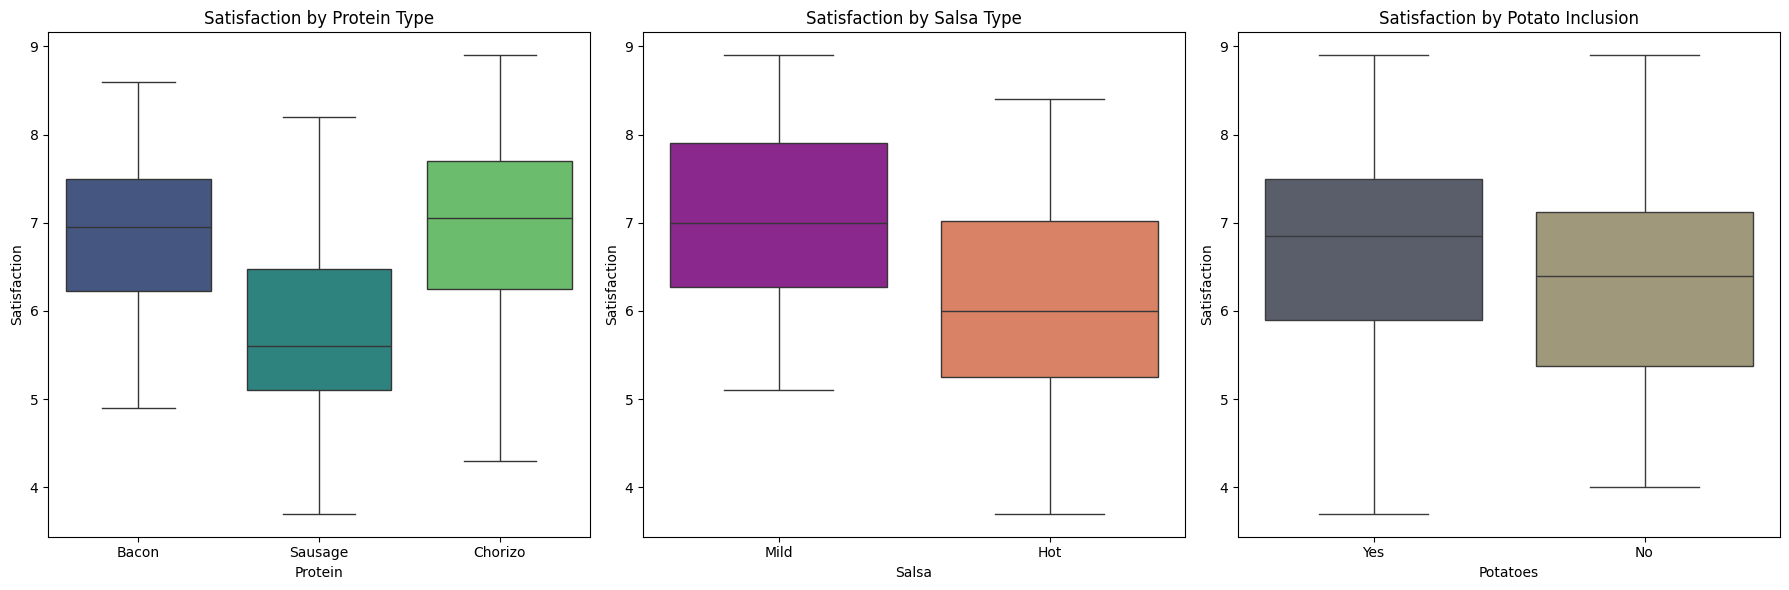

2-way interaction plots


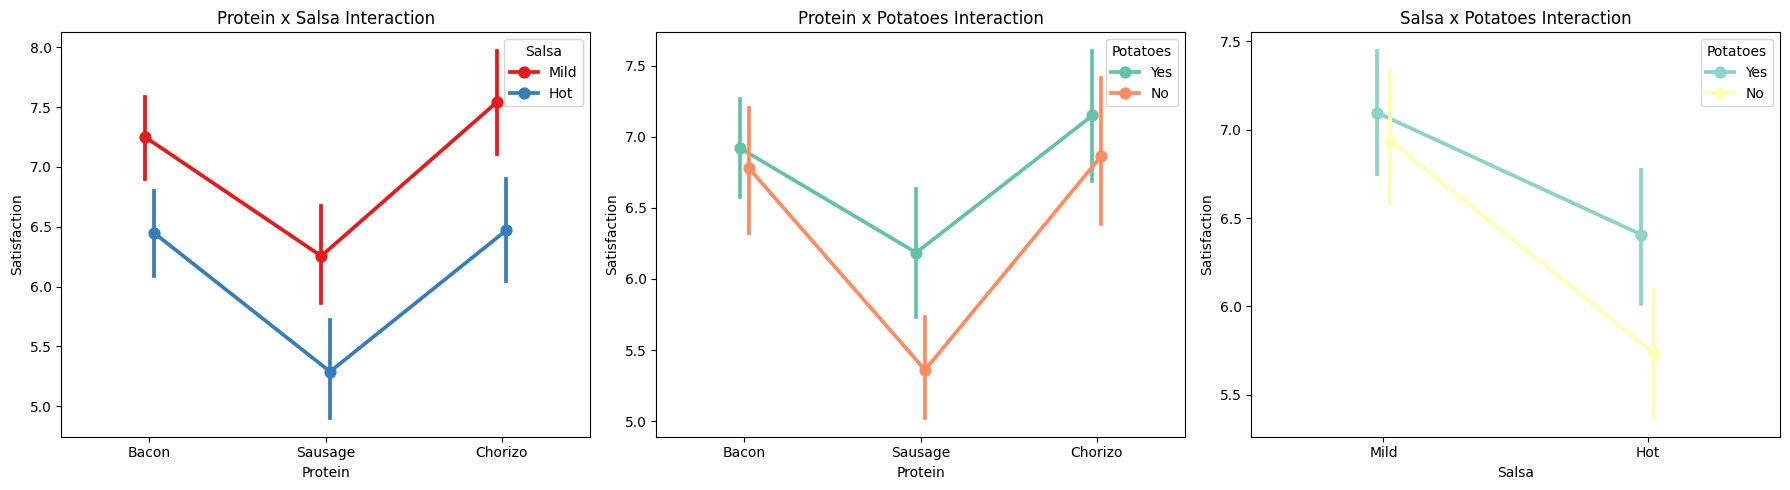

3-way interaction plots


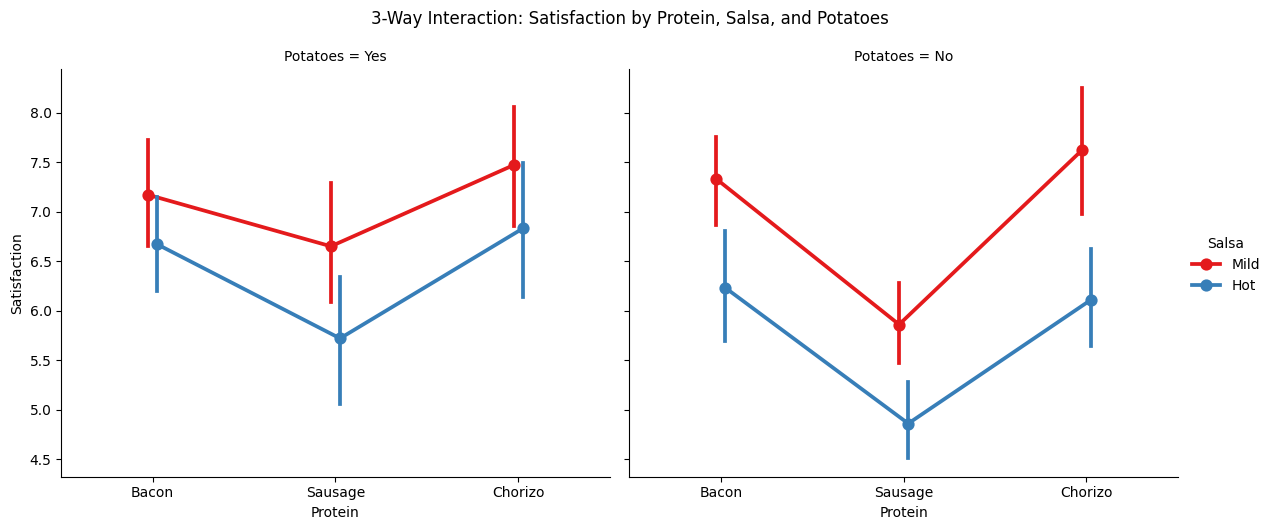

In [ ]:
## Question 6 Code ##

import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

BB_data = pd.read_excel("Busters Burritos.xlsx")
BB_data

print("Question 6: Exploratory Data Analysis")
print(BB_data.columns.tolist())
print(BB_data.describe(include="all").T)

print(BB_data.info())
print(BB_data.head())
print(BB_data.min())
print(BB_data.max())

# Group-by summary for Protein
protein_summary = BB_data.groupby('Protein')['Satisfaction'].agg(['mean', 'std']).reset_index()
print("Satisfaction by Protein:")
display(protein_summary)

# Group-by summary for Salsa
salsa_summary = BB_data.groupby('Salsa')['Satisfaction'].agg(['mean', 'std']).reset_index()
print("\nSatisfaction by Salsa:")
display(salsa_summary)

# Group-by summary for Potatoes
potatoes_summary = BB_data.groupby('Potatoes')['Satisfaction'].agg(['mean', 'std']).reset_index()
print("\nSatisfaction by Potatoes:")
display(potatoes_summary)

#EDA BOXPLOTS
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='Protein', y='Satisfaction', data=BB_data, ax=axes[0], palette='viridis')
axes[0].set_title('Satisfaction by Protein Type')

sns.boxplot(x='Salsa', y='Satisfaction', data=BB_data, ax=axes[1], palette='plasma')
axes[1].set_title('Satisfaction by Salsa Type')

sns.boxplot(x='Potatoes', y='Satisfaction', data=BB_data, ax=axes[2], palette='cividis')
axes[2].set_title('Satisfaction by Potato Inclusion')

plt.tight_layout()
plt.show()

print("2-way interaction plots")
# 2-Way Interaction Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Protein x Salsa
sns.pointplot(data=BB_data, x='Protein', y='Satisfaction', hue='Salsa', ax=axes[0], dodge=True, palette='Set1')
axes[0].set_title('Protein x Salsa Interaction')

# Protein x Potatoes
sns.pointplot(data=BB_data, x='Protein', y='Satisfaction', hue='Potatoes', ax=axes[1], dodge=True, palette='Set2')
axes[1].set_title('Protein x Potatoes Interaction')

# Salsa x Potatoes
sns.pointplot(data=BB_data, x='Salsa', y='Satisfaction', hue='Potatoes', ax=axes[2], dodge=True, palette='Set3')
axes[2].set_title('Salsa x Potatoes Interaction')

plt.tight_layout()
plt.show()

print("3-way interaction plots")
# 3-Way Interaction Plot (Protein x Salsa x Potatoes)
g = sns.catplot(data=BB_data, x='Protein', y='Satisfaction', hue='Salsa', col='Potatoes',
                kind='point', dodge=True, height=5, aspect=1.2, palette='Set1')
g.fig.suptitle('3-Way Interaction: Satisfaction by Protein, Salsa, and Potatoes', y=1.05)
plt.show()




7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

The assumption of Normality holds as the QQ plot shows that the points fall near the red line, visually supporting normality. Shapiro-Wilk Testing calculated a p-value of 0.6465, which is much higher than an alpha of 0.05, failing to reject the null hypothesis, concluding that the residuals are normally distributed.

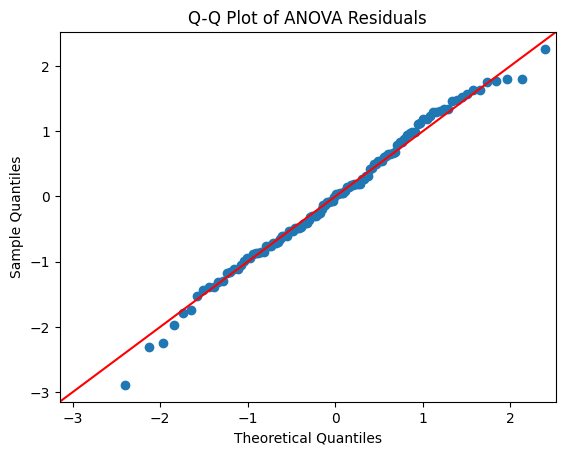

Shapiro-Wilk Test for Normality:
Test Statistic = 0.9912
p-value = 0.6465


In [ ]:
## Question 7 Code ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt

# Using C() to explicitly declare categorical variables
formula = 'Satisfaction ~ C(Protein) * C(Salsa) * C(Potatoes)'
burr_model = ols(formula, data=BB_data).fit()

# Get residuals
residuals = burr_model.resid

#Visual method: Q-Q plot
fig = sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of ANOVA Residuals')
plt.show()

#Testing method: Shapiro-Wilk test
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test for Normality:")
print(f"Test Statistic = {shapiro_test.statistic:.4f}")
print(f"p-value = {shapiro_test.pvalue:.4f}")


8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

The assumption of constant variance was tested with a visual method, the Residual vs Fitted Values plot. This was seen as the points are randomly scattered around the horizontal axis. The Levene's test was used as well to check the assumption of constant variance, which calculated a p-value of 0.8484. This is much larger than the alpha value of 0.05, we fail to reject the null hypothesis. This shows strong evidence that the variances are equal across all groups.

Levene's Test for Constant Variance:
Test Statistic: 0.5713
p-value: 0.8484


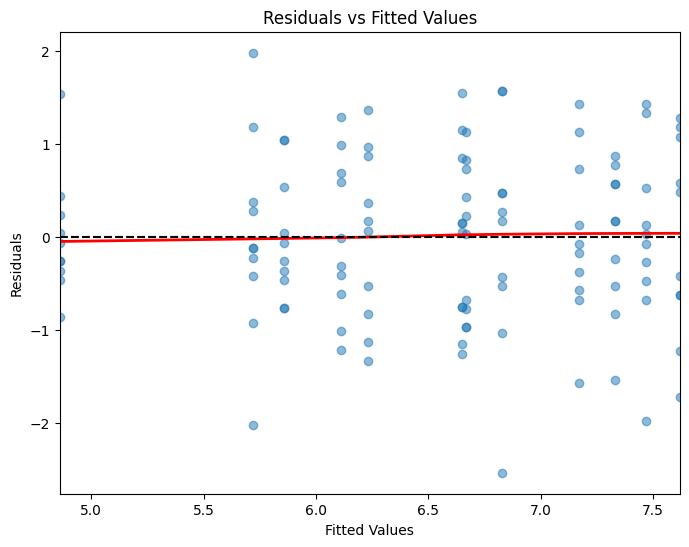

In [ ]:
## Question 8 Code ##
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Group data by all factor combinations
groups = [group['Satisfaction'].values for name, group in BB_data.groupby(['Protein', 'Salsa', 'Potatoes'])]

#Testing method: Levene's test
levene_stat, levene_p = stats.levene(*groups)
print("Levene's Test for Constant Variance:")
print(f"Test Statistic: {levene_stat:.4f}")
print(f"p-value: {levene_p:.4f}")

#Visual method: Residuals vs Fitted values plot
fitted_values = burr_model.fittedvalues
residuals = burr_model.resid

plt.figure(figsize=(8, 6))
sns.residplot(x=fitted_values, y=residuals, lowess=True, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 2})
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--')
plt.show()


9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

In [ ]:
## Question 9 Code ##

burr_model.summary()

burr_anova = sm.stats.anova_lm(burr_model, typ=2)

burr_anova

,sum_sq,df,F,PR(>F)
C(Protein),36.147167,2.0,21.193779,1.719650e-08
C(Salsa),26.885333,1.0,31.526775,1.541578e-07
C(Potatoes),5.208333,1.0,6.107492,1.502332e-02
C(Protein):C(Salsa),0.383167,2.0,0.224658,7.991617e-01
C(Protein):C(Potatoes),2.606167,2.0,1.528046,2.216124e-01
C(Salsa):C(Potatoes),1.976333,1.0,2.317524,1.308461e-01
C(Protein):C(Salsa):C(Potatoes),0.828167,2.0,0.485570,6.166832e-01
Residual,92.100000,108.0,NaN,NaN


10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

Based on the ANOVA results, none of the interaction effects are statistically significant (all p-values > 0.05), so post-hoc tests for interactions are not appropriate. However, all three main effects (Protein, Salsa, and Potatoes) are statistically significant (p-values < 0.05). We will run Tukey's HSD post-hoc tests to determine exactly which ingredient levels differ from each other, particularly for Protein, which has more than two levels. Between Protein, there is no significant difference in customer satisfaction between Bacon and Chorizo, however Sausage is significantly different from both Bacon and Chorizo with Sausage scoring lower on average. There is a significant difference between Hot and Mild Salsa, with mild salsa yielding higher satisfaction scores on average. The difference between having Potatoes and no potatoes resulted in  p-value of 0.053. This difference is considered borderline insignicant in this context, failing to reject.

In [ ]:
## Question 10 Code ##
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Post-hoc for Protein
print("Tukey HSD for Protein:")
tukey_protein = pairwise_tukeyhsd(endog=BB_data['Satisfaction'], groups=BB_data['Protein'], alpha=0.05)
print(tukey_protein)

# Post-hoc for Salsa
print("\nTukey HSD for Salsa:")
tukey_salsa = pairwise_tukeyhsd(endog=BB_data['Satisfaction'], groups=BB_data['Salsa'], alpha=0.05)
print(tukey_salsa)

# Post-hoc for Potatoes
print("\nTukey HSD for Potatoes:")
tukey_potatoes = pairwise_tukeyhsd(endog=BB_data['Satisfaction'], groups=BB_data['Potatoes'], alpha=0.05)
print(tukey_potatoes)


Tukey HSD for Protein:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  Bacon Chorizo   0.1575 0.7824  -0.402   0.717  False
  Bacon Sausage  -1.0775    0.0  -1.637  -0.518   True
Chorizo Sausage   -1.235    0.0 -1.7945 -0.6755   True
------------------------------------------------------

Tukey HSD for Salsa:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
   Hot   Mild   0.9467   0.0 0.5539 1.3394   True
-------------------------------------------------

Tukey HSD for Potatoes:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
    No    Yes   0.4167 0.053 -0.0056 0.8389  False
--------------------------------------------------


11. Calculate and interpret partial $\eta^2$ for the main effects.

Approximately 28.2% of the variance in customer satisfaction is explained by the type of protein used, holding all other factors constant. Salsa type explained 22.6% of the variance in satisfaction. However, the potato inclusion only accounted for 5.3% of the variance in satisfaction which is a much smaller effect size compared to the other 2 ingredients.

In [ ]:
## Question 11 Code ##

# Calculate partial eta squared
# Formula: SS_effect / (SS_effect + SS_residual)
ss_res = burr_anova.loc['Residual', 'sum_sq']
burr_anova['partial_eta_sq'] = burr_anova['sum_sq'] / (burr_anova['sum_sq'] + ss_res)

print("ANOVA Table with Partial Eta-Squared:")
display(burr_anova)

ANOVA Table with Partial Eta-Squared:


,sum_sq,df,F,PR(>F),partial_eta_sq
C(Protein),36.147167,2.0,21.193779,1.719650e-08,0.281855
C(Salsa),26.885333,1.0,31.526775,1.541578e-07,0.225955
C(Potatoes),5.208333,1.0,6.107492,1.502332e-02,0.053524
C(Protein):C(Salsa),0.383167,2.0,0.224658,7.991617e-01,0.004143
C(Protein):C(Potatoes),2.606167,2.0,1.528046,2.216124e-01,0.027518
C(Salsa):C(Potatoes),1.976333,1.0,2.317524,1.308461e-01,0.021008
C(Protein):C(Salsa):C(Potatoes),0.828167,2.0,0.485570,6.166832e-01,0.008912
Residual,92.100000,108.0,NaN,NaN,0.500000


12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

The overall experiment demonstrates that indivudal ingredient choices significantly drive customer satisfaction independently. Protein and Salsa are the most important factors, explaining the majority of the variance. Based on the post-hoc analysis, Mild salsa is highly preferred over Hot salsa. For protein, Bacon and Chorizo yield significantly higher satisfaction than sausage, although there is no meaningful difference between the two. The burrito combination I would include regularly would be Bacon or Chorizo burritos paired with mild salsa, with potatoes being a customer preference, but on by default. One of the limitations of this experiment is that the sample size is small, and lurking variables could also introduce variance into the satisfaction ratings. For future experiments, a larger sample size could be used. Blocking could be used with multiple burritos to control for individual taste preferences or for time of day to control for hunger levels.

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=3$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

The objective of this experiment is to identify the optimal combination of location, timing and marketing strategies to maximize sales for Buster's Breakfast Burritos, using a fractional factorial design to explore these factors.

2. Specify the outcome variable and how it is measured.

The outcome variable is "Sales Amount", measured in dollars (USD), representing the total sale generated on a day the food truck operates under specific conditions. This is a continuous numeric variable.

3. Specify the independent variables. What lurking variables may be present?

The independent variables are location, timing and marketing, each with 2 levels. Potential Lurking variables could include weather conditions, competitor proximity, order to fulfillment time.

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

A fractional factorial design is appropriate here because there are multiple factors and only 2 levels to each. This design allows for fewer runs compared to a full factorial design. Disadvantages of using this design is that main effects and interaction effects can be confounded with each other, making interpretation more complex. Additionally, higher order interactions are sacrificed to reduce the number of runs which could reduce generalizability of the study.

5. State the sets of null and alternative hypotheses for this experiment.


Because this is a $2^{3-1}$ fractional factorial design with the defining relation $I = ABC$, the main effects are confounded (aliased) with the two-way interactions. Specifically, $A = BC$, $B = AC$, and $C = AB$. Therefore, we test the following sets of hypotheses:

*   **Location (A) + Timing $\times$ Marketing (BC):**
    *   $H_0$: The main effect of Location and the Timing $\times$ Marketing interaction are both zero.
    *   $H_a$: The main effect of Location or the Timing $\times$ Marketing interaction (or both) is non-zero.

*   **Timing (B) + Location $\times$ Marketing (AC):**
    *   $H_0$: The main effect of Timing and the Location $\times$ Marketing interaction are both zero.
    *   $H_a$: The main effect of Timing or the Location $\times$ Marketing interaction (or both) is non-zero.

*   **Marketing (C) + Location $\times$ Timing (AB):**
    *   $H_0$: The main effect of Marketing and the Location $\times$ Timing interaction are both zero.
    *   $H_a$: The main effect of Marketing or the Location $\times$ Timing interaction (or both) is non-zero.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

Question 6: Exploratory Data Analysis
['Location', 'Timing', 'Marketing', 'Sales']
          count unique          top freq         mean         std     min  \
Location     24      2      Brewery   12          NaN         NaN     NaN   
Timing       24      2      Weekday   12          NaN         NaN     NaN   
Marketing    24      2  Independent   12          NaN         NaN     NaN   
Sales      24.0    NaN          NaN  NaN  1049.980417  243.067213  660.46   

                25%      50%        75%      max  
Location        NaN      NaN        NaN      NaN  
Timing          NaN      NaN        NaN      NaN  
Marketing       NaN      NaN        NaN      NaN  
Sales      814.4725  1068.28  1234.2825  1492.71  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   24 non-null     object 
 1   Timing     24 non-null     object 
 2   Marketing

/tmp/ipykernel_6037/1313892334.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipykernel_6037/1313892334.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipykernel_6037/1313892334.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



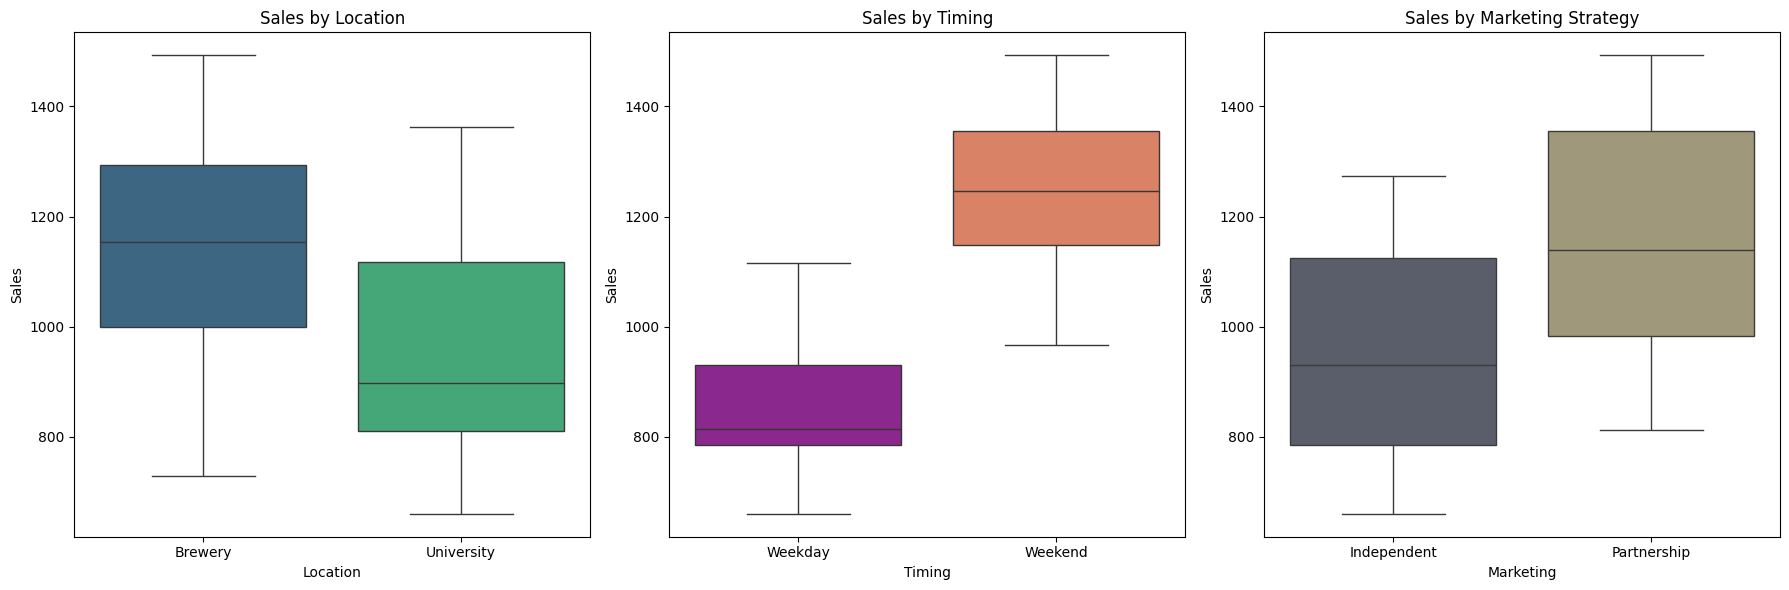

In [19]:
## Question 6 Code ##

import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

BBS_data = pd.read_excel("Busters Burrito Sales.xlsx")
BBS_data

print("Question 6: Exploratory Data Analysis")
print(BBS_data.columns.tolist())
print(BBS_data.describe(include="all").T)

print(BBS_data.info())
print(BBS_data.head())
print(BBS_data.min())
print(BBS_data.max())

# Set up the figure for three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Boxplot for Sales by Location
sns.boxplot(x='Location', y='Sales', data=BBS_data, ax=axes[0], palette='viridis')
axes[0].set_title('Sales by Location')

# Boxplot for Sales by Timing
sns.boxplot(x='Timing', y='Sales', data=BBS_data, ax=axes[1], palette='plasma')
axes[1].set_title('Sales by Timing')

# Boxplot for Sales by Marketing
sns.boxplot(x='Marketing', y='Sales', data=BBS_data, ax=axes[2], palette='cividis')
axes[2].set_title('Sales by Marketing Strategy')

plt.tight_layout()
plt.show()

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

The main effects are confounded (aliased) with the two-way interactions. Specifically,  A=BC ,  B=AC , and  C=AB . This means that they will be the same value and carry the same impact.

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

To assess the assumption of normality, we use a visual and a testing method. For a visual method we use a QQ plot, which does not have anomalies. All the points seem to be around the red line in no discernable pattern. For a testing method, we use Shapiro-Wilk test. The p-value calculated from this test was 0.9362, which is absolutely above the alpha value of 0.05. This means we fail to reject the null hypothesis of normality.

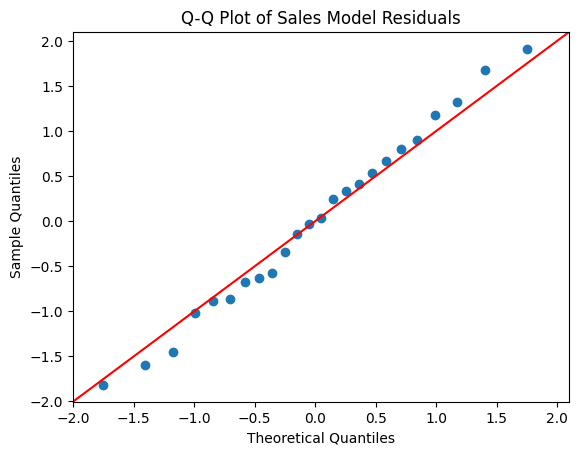

Shapiro-Wilk Test for Normality:
Test Statistic = 0.9824
p-value = 0.9362


In [21]:
## Question 8 Code ##

import statsmodels.api as sm
from statsmodels.formula.api import ols

#Fitting the model with main effects
sales_model = ols('Sales ~ C(Location) + C(Timing) + C(Marketing)', data=BBS_data).fit()

#residuals
residuals_sales = sales_model.resid

#Q-Q plot
fig = sm.qqplot(residuals_sales, line='45', fit=True)
plt.title('Q-Q Plot of Sales Model Residuals')
plt.show()

#Shapiro-Wilk test
shapiro_test = stats.shapiro(residuals_sales)
print(f"Shapiro-Wilk Test for Normality:")
print(f"Test Statistic = {shapiro_test.statistic:.4f}")
print(f"p-value = {shapiro_test.pvalue:.4f}")

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

Using a testing method of Levene's Test, we calculated the p-value to be 0.7796. This concludes that we can fail to reject the null hypothesis of constant variance due to the value being way above the alpha value of 0.05. The visual testing reveals no anomalies either with points being randomly distributed around the horizontal line.

Levene's Test for Constant Variance (Sales Model):
Test Statistic: 0.5568
p-value: 0.7796


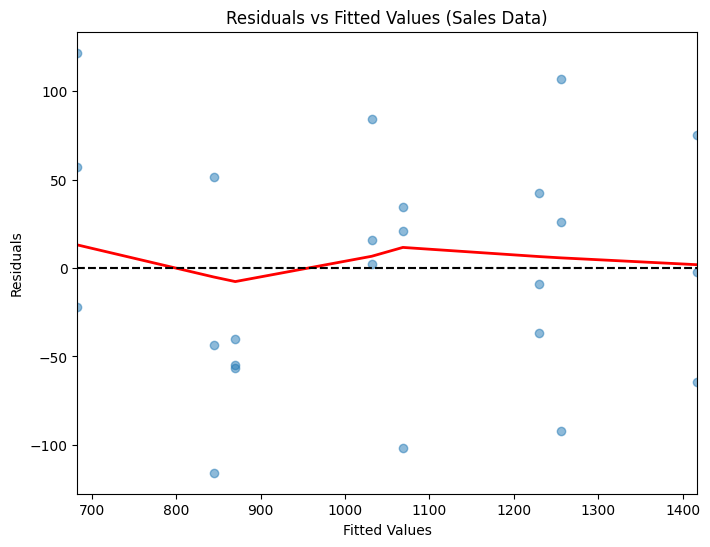

In [22]:
## Question 9 Code ##

#Testing method: Levene's test
# Grouping the sales data by the observed treatment combinations in the fractional design
groups_sales = [group['Sales'].values for name, group in BBS_data.groupby(['Location', 'Timing', 'Marketing'])]
levene_stat_sales, levene_p_sales = stats.levene(*groups_sales)

print("Levene's Test for Constant Variance (Sales Model):")
print(f"Test Statistic: {levene_stat_sales:.4f}")
print(f"p-value: {levene_p_sales:.4f}")

#Visual method: Residuals vs Fitted values plot
fitted_sales = sales_model.fittedvalues
resid_sales = sales_model.resid

plt.figure(figsize=(8, 6))
sns.residplot(x=fitted_sales, y=resid_sales, lowess=True,
             scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 2})
plt.title('Residuals vs Fitted Values (Sales Data)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--')
plt.show()

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

The ANOVA results show that all three main effects are statistically significant, as their p-values are all less than an alpha value of 0.05. Because these P-values are small, we have strong evidence to reject the null hypothesis in favor of the alternative hypothesis. This suggests that all three variables - Timing, marketing and location all signficantly influcence the faily sales amount, or that the aliased two-way interactions are significant.

In [ ]:
## Question 10 Code ##

print("Model Fit Summary:")
display(sales_model.summary())

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [24]:
## Question 11 Code ##

# Calculate main effects
# Location: University (+) vs Brewery (-)
# Timing: Weekend (+) vs Weekday (-)
# Marketing: Partnership (+) vs Independent (-)

# Mean Sales for each level
loc_effect = BBS_data.groupby('Location')['Sales'].mean()
time_effect = BBS_data.groupby('Timing')['Sales'].mean()
mark_effect = BBS_data.groupby('Marketing')['Sales'].mean()

print("Average Sales by Factor Level:")
print(f"\nLocation:\n{loc_effect}")
print(f"\nTiming:\n{time_effect}")
print(f"\nMarketing:\n{mark_effect}")

# Numerical calculation of the effects (High - Low)
effect_A = loc_effect['University'] - loc_effect['Brewery']
effect_B = time_effect['Weekend'] - time_effect['Weekday']
effect_C = mark_effect['Partnership'] - mark_effect['Independent']

print("\nNumerical Main Effects:")
print(f"Location (A) Effect: {effect_A:.2f}")
print(f"Timing (B) Effect: {effect_B:.2f}")
print(f"Marketing (C) Effect: {effect_C:.2f}")

Average Sales by Factor Level:

Location:
Location
Brewery       1130.844167
University     969.116667
Name: Sales, dtype: float64

Timing:
Timing
Weekday     856.971667
Weekend    1242.989167
Name: Sales, dtype: float64

Marketing:
Marketing
Independent     956.325833
Partnership    1143.635000
Name: Sales, dtype: float64

Numerical Main Effects:
Location (A) Effect: -161.73
Timing (B) Effect: 386.02
Marketing (C) Effect: 187.31


12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

Based on the partial eta squared values, we see that Timing has the largest effect size, explaining about 90.2% of the variance in sales. Marketing is next at 0.684 and Location is 0.617. This confirms that timing is the most important factor.

In [25]:
## Question 12 Code ##
import statsmodels.api as sm

# Calculate ANOVA table for the sales model
sales_anova = sm.stats.anova_lm(sales_model, typ=2)

# Calculate partial eta squared
# Formula: SS_effect / (SS_effect + SS_residual)
ss_res_sales = sales_anova.loc['Residual', 'sum_sq']
sales_anova['partial_eta_sq'] = sales_anova['sum_sq'] / (sales_anova['sum_sq'] + ss_res_sales)

print("ANOVA Table with Partial Eta-Squared for Sales Model:")
display(sales_anova)

ANOVA Table with Partial Eta-Squared for Sales Model:


,sum_sq,df,F,PR(>F),partial_eta_sq
C(Location),156934.705537,1.0,32.231966,1.479823e-05,0.617093
C(Timing),894057.061837,1.0,183.625521,1.542764e-11,0.901780
C(Marketing),210508.343504,1.0,43.235165,2.091894e-06,0.683720
Residual,97378.301017,20.0,NaN,NaN,0.500000


13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

The experiment demonstrates that Timing, Marketing and Location all significantly impact daily sales, with Timing driving the majority of the varience. To maximize sales, Busters Breakfast Burritos should operate on the Weekend, Utilize a partnership marketing strategy and set up at the brewery. Some limitations are with the design of the experiment. This is because the main effects are aliased with two-way interactions, we have to assume the interactions are negligible to interpret the main effects. The sample size is small and lurking variables were not controlled for. In the future, conduction a full factorial design would allow us to de-alias the main effects and we could evaluate every interaction directly. Increasing the sample size would help and blocking could be utilized to control for variables.

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

3. What is the difference between a fixed effect and a random effect?

4. What is the most important thing you learned in this class?